# Importing Required Libraries

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import seaborn as sns
import matplotlib.pyplot as plt


### Loading the UrbanEV Dataset

- Multiple UrbanEV data files were loaded to construct a comprehensive urban charging network dataset.  
- The datasets include:
  - occupancy levels,
  - charging volume,
  - pricing information,
  - station metadata,
  - and timestamp references.  

- Dataset dimensions were inspected to verify successful loading and understand the structure of each component before preprocessing and integration.

In [2]:

# Load main files
occupancy = pd.read_csv("dataset/UrbanEV/occupancy.csv")

volume = pd.read_csv("dataset/UrbanEV/volume.csv")

price = pd.read_csv("dataset/UrbanEV/price.csv")

stations = pd.read_csv("dataset/UrbanEV/stations.csv")

time_df = pd.read_csv("dataset/UrbanEV/time.csv")

# Shapes
print("occupancy:", occupancy.shape)
print("volume:", volume.shape)
print("price:", price.shape)
print("stations:", stations.shape)
print("time:", time_df.shape)

occupancy: (8640, 248)
volume: (8640, 248)
price: (8640, 248)
stations: (1706, 6)
time: (8640, 6)


### Initial Dataset Inspection

- The column names and sample records were inspected to understand the structure and organization of the UrbanEV datasets.  
- Occupancy data was examined to identify charging station occupancy patterns across time intervals.  
- The time reference dataset was reviewed to understand timestamp formatting and temporal alignment requirements.  

This inspection step helps:
- identify key variables,
- validate dataset structure,
- and prepare the data for preprocessing and integration.

In [3]:
# Columns
print("Occupancy Columns:")
print(occupancy.columns[:10])

print("\nTime Columns:")
print(time_df.columns)

# Preview
print("\nOccupancy Head:")
print(occupancy.head())

print("\nTime Head:")
print(time_df.head())

Occupancy Columns:
Index(['timestamp', '102', '105', '107', '108', '109', '110', '111', '115',
       '123'],
      dtype='object')

Time Columns:
Index(['month', 'day', 'year', 'hour', 'minute', 'second'], dtype='object')

Occupancy Head:
   timestamp  102  105  107  108  109  110  111  115  123  ...  1160  1162  \
0          1   12   16   24   15    6    8   24    1    2  ...     0    12   
1          2   12   16   24   15    6    8   24    1    2  ...     0    12   
2          3   12   16   24   15    6    8   24    1    2  ...     0    12   
3          4   12   16   24   15    6    8   24    1    2  ...     0    12   
4          5   12   16   24   15    6    8   24    1    2  ...     0    12   

   1163  1164  1166  1167  1168  1170  1172  1173  
0     1    38    26   162    10     1     8    15  
1     1    38    26   162    10     1     8    15  
2     1    38    26   164    10     1     8    15  
3     1    38    26   166    10     1     8    15  
4     1    38    26   168    10

### Timestamp Reconstruction

- A unified datetime column was created by combining the year, month, day, hour, minute, and second components from the time dataset.  
- This step converts fragmented temporal information into a standard timestamp format suitable for time-series analysis.  
- Proper timestamp reconstruction is essential for:
  - temporal alignment,
  - occupancy tracking,
  - demand forecasting,
  - and congestion analysis.

In [4]:
# Create datetime column
time_df['timestamp'] = pd.to_datetime({
    'year': time_df['year'],
    'month': time_df['month'],
    'day': time_df['day'],
    'hour': time_df['hour'],
    'minute': time_df['minute'],
    'second': time_df['second']
})

# Check
time_df[['timestamp']].head()

,timestamp
0,2022-06-19 00:00:00
1,2022-06-19 00:05:00
2,2022-06-19 00:10:00
3,2022-06-19 00:15:00
4,2022-06-19 00:20:00


### Creating the Unified UrbanEV Analytical Dataset

- The occupancy dataset was combined with the reconstructed timestamp information to create a unified time-indexed analytical table.  
- A standardized timestamp column was added to align occupancy observations with temporal charging activity.  
- The timestamp field was repositioned for improved readability and easier time-series processing.  

This unified dataset forms the foundation for:
- occupancy analysis,
- temporal demand modeling,
- congestion monitoring,
- and dynamic pricing evaluation.

In [5]:
# Copy occupancy data
urban_df = occupancy.copy()

# Replace timestamp column
urban_df['timestamp'] = time_df['timestamp']

# Move timestamp to first column
cols = urban_df.columns.tolist()

cols = ['timestamp'] + [
    c for c in cols
    if c != 'timestamp'
]

urban_df = urban_df[cols]

# Check
print(urban_df.shape)

urban_df.head()

(8640, 248)


,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,2022-06-19 00:00:00,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
1,2022-06-19 00:05:00,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
2,2022-06-19 00:10:00,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,164,10,1,8,15
3,2022-06-19 00:15:00,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,166,10,1,8,15
4,2022-06-19 00:20:00,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,168,10,1,8,15


### Transforming Occupancy Data to Long Format

- The occupancy matrix was transformed from wide format to long format to create a structured time-series dataset.  
- Each row now represents:
  - a timestamp,
  - a charging station,
  - and its corresponding occupancy level.

In [6]:
# Convert wide matrix -> long format
urban_long = urban_df.melt(
    id_vars='timestamp',
    var_name='station_id',
    value_name='occupancy'
)

# Convert station IDs to string
urban_long['station_id'] = (
    urban_long['station_id']
    .astype(str)
)

# Check
print(urban_long.shape)

urban_long.head()

(2134080, 3)


,timestamp,station_id,occupancy
0,2022-06-19 00:00:00,102,12
1,2022-06-19 00:05:00,102,12
2,2022-06-19 00:10:00,102,12
3,2022-06-19 00:15:00,102,12
4,2022-06-19 00:20:00,102,12


### Temporal Feature Engineering

- Time-based features were extracted from timestamps to analyze temporal occupancy and charging behavior patterns.  
- Features such as hour, day of week, month, and weekend indicators help identify:
  - peak occupancy periods,
  - weekday vs weekend usage behavior,
  - and seasonal charging trends.  

- A separate date field was also created to support daily aggregation and time-series analysis.

In [7]:
# Hour of day
urban_long['hour'] = (
    urban_long['timestamp'].dt.hour
)

# Day of week
urban_long['day_of_week'] = (
    urban_long['timestamp'].dt.dayofweek
)

# Month
urban_long['month'] = (
    urban_long['timestamp'].dt.month
)

# Weekend flag
urban_long['is_weekend'] = (
    urban_long['day_of_week'] >= 5
).astype(int)

# Date
urban_long['date'] = (
    urban_long['timestamp'].dt.date
)

# Check
urban_long.head()

,timestamp,station_id,occupancy,hour,day_of_week,month,is_weekend,date
0,2022-06-19 00:00:00,102,12,0,6,6,1,2022-06-19
1,2022-06-19 00:05:00,102,12,0,6,6,1,2022-06-19
2,2022-06-19 00:10:00,102,12,0,6,6,1,2022-06-19
3,2022-06-19 00:15:00,102,12,0,6,6,1,2022-06-19
4,2022-06-19 00:20:00,102,12,0,6,6,1,2022-06-19


### Hourly Occupancy Analysis

- Average charging station occupancy was analyzed across different hours of the day to identify temporal utilization patterns within the UrbanEV network.  
- The hourly occupancy curve helps detect:
  - peak utilization periods,
  - low-demand intervals,
  - and daily charging behavior trends.  

- This analysis provides insights into network congestion dynamics and operational charging demand distribution.

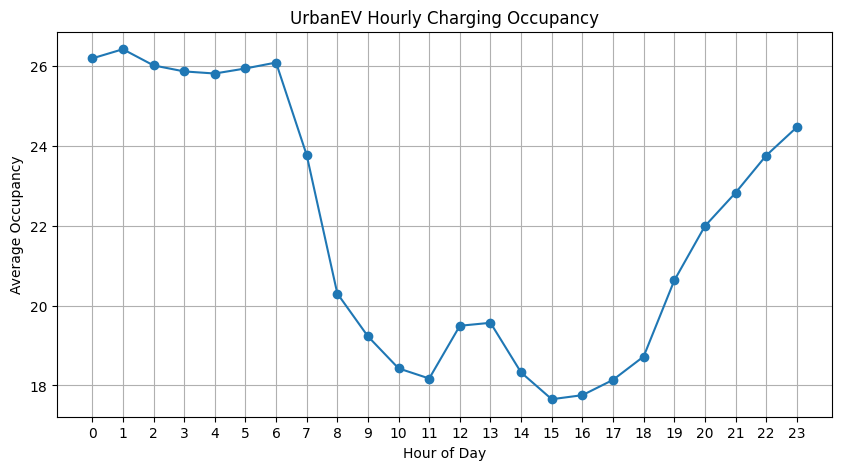

In [8]:


# Average occupancy by hour
hourly_demand = (
    urban_long
    .groupby('hour')['occupancy']
    .mean()
)

# Plot
plt.figure(figsize=(10,5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker='o'
)

plt.xlabel("Hour of Day")

plt.ylabel("Average Occupancy")

plt.title("UrbanEV Hourly Charging Occupancy")

plt.xticks(range(24))

plt.grid(True)

plt.show()

### Weekday vs Weekend Occupancy Analysis

- Average charging station occupancy was compared between weekdays and weekends to analyze differences in urban charging behavior.  
- This comparison helps identify:
  - commuter-driven charging patterns,
  - variations in infrastructure utilization,
  - and temporal demand differences across the UrbanEV network.

In [9]:
# Weekday vs weekend occupancy
weekend_analysis = (
    urban_long
    .groupby('is_weekend')
    .agg(
        avg_occupancy=('occupancy', 'mean')
    )
)

print(weekend_analysis)

            avg_occupancy
is_weekend               
0               21.661014
1               22.464447


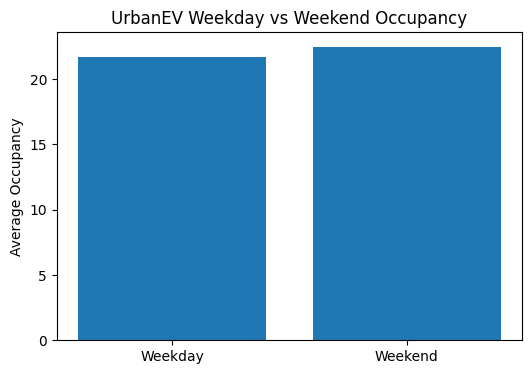

In [10]:


plt.figure(figsize=(6,4))

plt.bar(
    ['Weekday', 'Weekend'],
    weekend_analysis['avg_occupancy']
)

plt.ylabel("Average Occupancy")

plt.title("UrbanEV Weekday vs Weekend Occupancy")

plt.show()

### Occupancy Heatmap Analysis

- A heatmap was created to visualize average charging station occupancy across different days of the week and hours of the day.  
- The visualization helps identify:
  - peak congestion periods,
  - high-utilization time windows,
  - and temporal occupancy patterns within the UrbanEV network.  

- Darker regions indicate periods of higher charging station occupancy and increased infrastructure usage intensity.

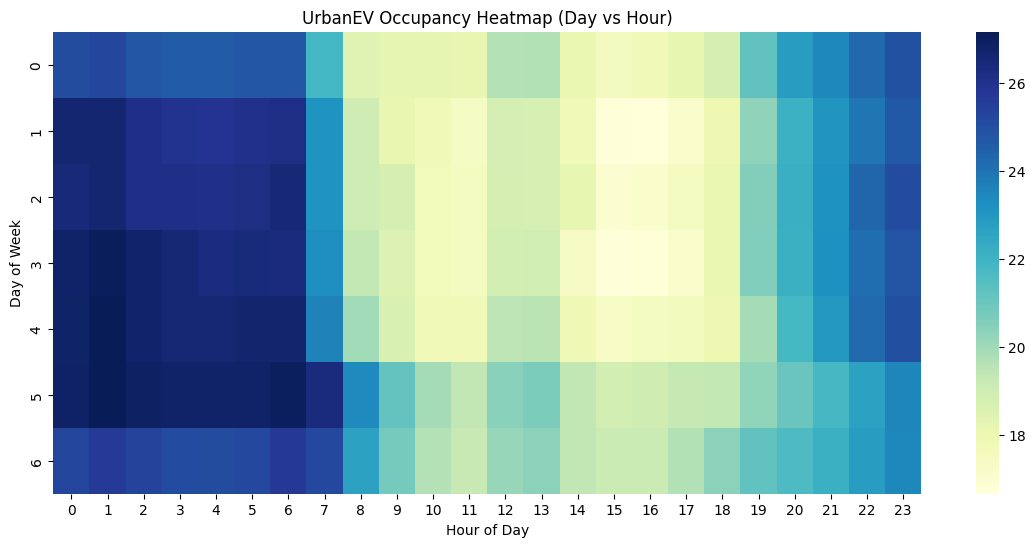

In [11]:


# Heatmap data
heatmap_data = (
    urban_long
    .groupby(['day_of_week', 'hour'])['occupancy']
    .mean()
    .unstack()
)

# Plot
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("UrbanEV Occupancy Heatmap (Day vs Hour)")

plt.xlabel("Hour of Day")

plt.ylabel("Day of Week")

plt.show()

In [12]:
# Aggregate occupancy over time
demand_df = (
    urban_long
    .groupby('timestamp')
    .agg(
        avg_occupancy=('occupancy', 'mean')
    )
    .reset_index()
)

# Sort chronologically
demand_df = demand_df.sort_values('timestamp')

# Check
print(demand_df.shape)

demand_df.head()

(8640, 2)


,timestamp,avg_occupancy
0,2022-06-19 00:00:00,24.352227
1,2022-06-19 00:05:00,24.356275
2,2022-06-19 00:10:00,24.643725
3,2022-06-19 00:15:00,24.923077
4,2022-06-19 00:20:00,25.072874


In [13]:
# Time features
demand_df['hour'] = (
    demand_df['timestamp'].dt.hour
)

demand_df['day_of_week'] = (
    demand_df['timestamp'].dt.dayofweek
)

demand_df['month'] = (
    demand_df['timestamp'].dt.month
)

# Lag features
demand_df['lag_1'] = (
    demand_df['avg_occupancy']
    .shift(1)
)

# 24 hours earlier
# 24*12 because data is every 5 minutes
demand_df['lag_288'] = (
    demand_df['avg_occupancy']
    .shift(288)
)

# Rolling averages
demand_df['rolling_mean_12'] = (
    demand_df['avg_occupancy']
    .rolling(window=12)
    .mean()
)

# 1-hour rolling average
demand_df['rolling_mean_288'] = (
    demand_df['avg_occupancy']
    .rolling(window=288)
    .mean()
)

# Drop NaNs
demand_df = demand_df.dropna()

# Check
print(demand_df.shape)

demand_df.head()

(8352, 9)


,timestamp,avg_occupancy,hour,day_of_week,month,lag_1,lag_288,rolling_mean_12,rolling_mean_288
288,2022-06-20 00:00:00,23.392713,0,0,6,23.259109,24.352227,22.951080,21.949449
289,2022-06-20 00:05:00,23.603239,0,0,6,23.392713,24.356275,23.026653,21.946834
290,2022-06-20 00:10:00,23.813765,0,0,6,23.603239,24.643725,23.118421,21.943952
291,2022-06-20 00:15:00,24.113360,0,0,6,23.813765,24.923077,23.229420,21.941141
292,2022-06-20 00:20:00,24.279352,0,0,6,24.113360,25.072874,23.351552,21.938386


### Occupancy Forecasting Using Random Forest

- A Random Forest Regressor was used to predict average charging station occupancy based on temporal and historical occupancy patterns.  
- Time-based features, lag variables, and rolling averages were used to capture occupancy dynamics and recurring utilization trends within the UrbanEV network.  
- A time-series train-test split was applied to preserve chronological order and prevent data leakage during model evaluation.  

Model performance was evaluated using:
- MAE (Mean Absolute Error),
- RMSE (Root Mean Squared Error),
- and R² Score.

In [14]:


# Features
features = [
    'hour',
    'day_of_week',
    'month',
    'lag_1',
    'lag_288',
    'rolling_mean_12',
    'rolling_mean_288'
]

X = demand_df[features]

y = demand_df['avg_occupancy']

# Time-series split
split_index = int(len(demand_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.14416862311835377
RMSE: 0.43825813837463573
R2  : 0.9851133748460448


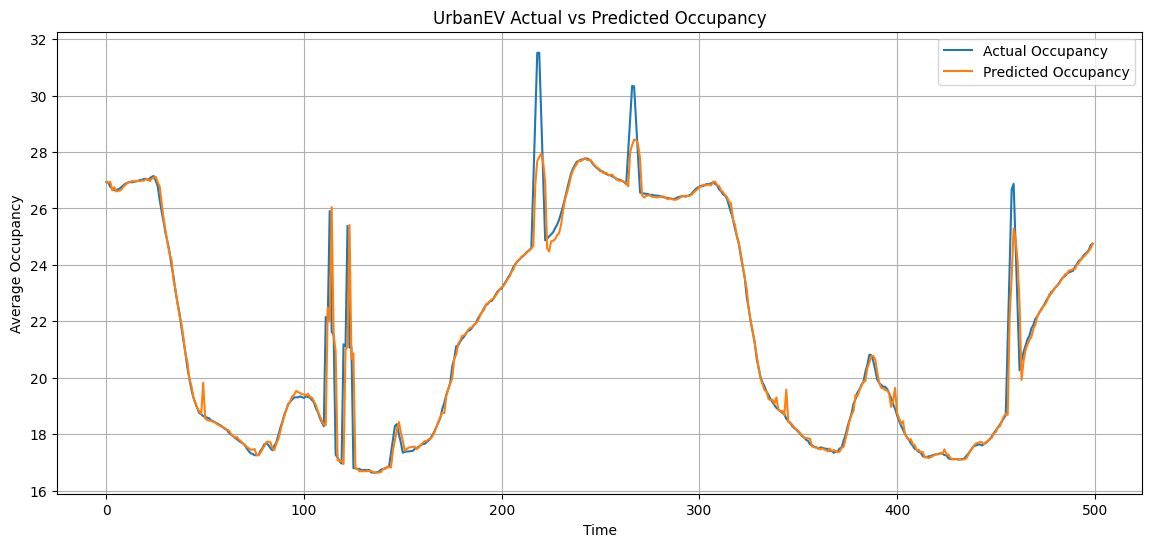

In [15]:


# Plot
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:500],
    label='Actual Occupancy'
)

plt.plot(
    y_pred[:500],
    label='Predicted Occupancy'
)

plt.xlabel("Time")

plt.ylabel("Average Occupancy")

plt.title("UrbanEV Actual vs Predicted Occupancy")

plt.legend()

plt.grid(True)

plt.show()

### Dynamic Tariff Optimization

- A rule-based dynamic pricing strategy was implemented using charging station occupancy levels as a congestion indicator.  
- Surge pricing was applied during high-occupancy periods, while discounted pricing was introduced during low-utilization intervals.  
- Revenue generated under adaptive pricing was compared with baseline static pricing to evaluate pricing effectiveness and operational monetization improvement.  

The pricing framework includes:
- ₹22 during high congestion,
- ₹15 under normal utilization,
- and ₹10 during low-demand periods.

In [16]:
# Base tariff
BASE_PRICE = 15

# Dynamic pricing logic
def dynamic_price(occupancy):

    if occupancy >= 26:
        return 22      # High congestion surge pricing

    elif occupancy <= 18:
        return 10      # Low utilization discount

    else:
        return 15      # Normal pricing

# Apply pricing
demand_df['dynamic_tariff'] = (
    demand_df['avg_occupancy']
    .apply(dynamic_price)
)

# Baseline revenue proxy
demand_df['baseline_revenue'] = (
    demand_df['avg_occupancy'] *
    BASE_PRICE
)

# Dynamic revenue proxy
demand_df['dynamic_revenue'] = (
    demand_df['avg_occupancy'] *
    demand_df['dynamic_tariff']
)

# Revenue uplift
demand_df['revenue_gain_pct'] = (
    (
        demand_df['dynamic_revenue']
        -
        demand_df['baseline_revenue']
    )
    /
    demand_df['baseline_revenue']
) * 100

# Check
demand_df[[
    'avg_occupancy',
    'dynamic_tariff',
    'baseline_revenue',
    'dynamic_revenue',
    'revenue_gain_pct'
]].head()

,avg_occupancy,dynamic_tariff,baseline_revenue,dynamic_revenue,revenue_gain_pct
288,23.392713,15,350.890688,350.890688,0.0
289,23.603239,15,354.048583,354.048583,0.0
290,23.813765,15,357.206478,357.206478,0.0
291,24.113360,15,361.700405,361.700405,0.0
292,24.279352,15,364.190283,364.190283,0.0


### Revenue Uplift Evaluation

- Total revenue under baseline static pricing was compared with revenue generated using the dynamic pricing strategy.  
- Revenue uplift percentage was calculated to measure the financial impact of occupancy-aware adaptive pricing.  
- This evaluation helps assess the effectiveness of dynamic tariff optimization in improving charging network monetization.

In [17]:
# Total baseline revenue
baseline_total = (
    demand_df['baseline_revenue']
    .sum()
)

# Total dynamic revenue
dynamic_total = (
    demand_df['dynamic_revenue']
    .sum()
)

# Revenue uplift %
uplift_pct = (
    (
        dynamic_total -
        baseline_total
    )
    /
    baseline_total
) * 100

print("Baseline Revenue :", baseline_total)

print("Dynamic Revenue  :", dynamic_total)

print("Revenue Uplift % :", uplift_pct)

Baseline Revenue : 2743668.825910931
Dynamic Revenue  : 2910139.4736842103
Revenue Uplift % : 6.067446850769575


### Dynamic Tariff Distribution Analysis

- The frequency of different tariff levels was analyzed to evaluate how often surge, normal, and discount pricing conditions occurred within the UrbanEV network.  
- The tariff distribution highlights occupancy-driven congestion patterns and overall charging infrastructure utilization behavior.  
- This analysis helps assess the operational stability and responsiveness of the adaptive pricing strategy.

dynamic_tariff
10    1450
15    5348
22    1554
Name: count, dtype: int64


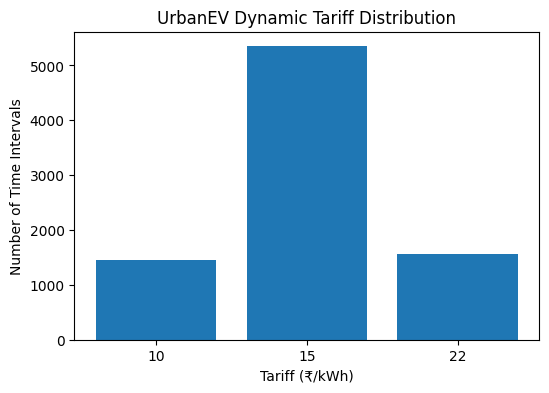

In [18]:


# Tariff counts
tariff_counts = (
    demand_df['dynamic_tariff']
    .value_counts()
    .sort_index()
)

print(tariff_counts)

# Plot
plt.figure(figsize=(6,4))

plt.bar(
    tariff_counts.index.astype(str),
    tariff_counts.values
)

plt.xlabel("Tariff (₹/kWh)")

plt.ylabel("Number of Time Intervals")

plt.title("UrbanEV Dynamic Tariff Distribution")

plt.show()